In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("GSE1000_series_matrix.txt", sep="\t", comment="!", header=None)
df.head()


,0,1,2,3,4,5,6,7,8,9,10
0,ID_REF,GSM15785,GSM15786,GSM15787,GSM15788,GSM15789,GSM15790,GSM15791,GSM15792,GSM15794,GSM15795
1,1007_s_at,320.4648708,232.9942945,321.1989997,299.2894447,292.0158744,247.2142626,245.7803605,222.2537593,239.0416401,305.3781325
2,1053_at,388.4570282,422.9093542,369.8441957,348.2636943,384.6797086,375.4117411,363.9898893,382.8768359,390.2117945,339.2314569
3,117_at,65.47251742,64.10611396,68.17089422,62.67997335,66.1750872,52.31132627,59.67616474,71.36348486,52.21510692,64.44750168
4,121_at,512.2466824,439.1625349,518.2708088,455.0033648,493.7479397,513.9687769,499.749209,461.6982917,441.9870046,495.7990653


In [36]:
# Cell 1: Load and parse Series Matrix
import pandas as pd
import numpy as np
import re
from io import StringIO

file_path = "GSE1000_series_matrix.txt"
with open(file_path, 'r') as f:
    lines = f.readlines()

# Extract expression data block
start_idx = next(i for i, line in enumerate(lines) if line.startswith("!series_matrix_table_begin")) + 1
end_idx   = next(i for i, line in enumerate(lines) if line.startswith("!series_matrix_table_end"))
data_block = "".join(lines[start_idx:end_idx])

df_expr = pd.read_csv(StringIO(data_block), sep="\t")
df_expr.rename(columns={df_expr.columns[0]: 'probe_id'}, inplace=True)

# Extract sample titles
titles = next(line for line in lines if line.startswith("!Sample_title")).strip().split("\t")[1:]
meta = []
for sid, title in zip(df_expr.columns[1:], titles):
    m = re.match(r'"?(.+?)\s+(\d+)\s*hours"?$', title)
    if not m:
        raise ValueError(f"Cannot parse sample title: {title}")
    surface, tp = m.groups()
    tp = int(tp)
    meta.append({
        'sample_id': sid,
        'surface': surface.strip(),
        'time_point': f"{tp}h",
        'condition_num': 0 if tp == 6 else 1
    })
meta_df = pd.DataFrame(meta)
# Align expression matrix
df_expr.set_index('probe_id', inplace=True)

Number of probes: 22283Number of samples: 10
Top 5 rows of the expression matrix:
             GSM15785    GSM15786    GSM15787    GSM15788    GSM15789  \
probe_id                                                                
1007_s_at  320.464871  232.994294  321.199000  299.289445  292.015874   
1053_at    388.457028  422.909354  369.844196  348.263694  384.679709   
117_at      65.472517   64.106114   68.170894   62.679973   66.175087   
121_at     512.246682  439.162535  518.270809  455.003365  493.747940   
1255_g_at   23.005649   22.930349   23.535910   22.126089   21.920424   

             GSM15790    GSM15791    GSM15792    GSM15794    GSM15795  
probe_id                                                               
1007_s_at  247.214263  245.780361  222.253759  239.041640  305.378132  
1053_at    375.411741  363.989889  382.876836  390.211794  339.231457  
117_at      52.311326   59.676165   71.363485   52.215107   64.447502  
121_at     513.968777  499.749209  461.698292 

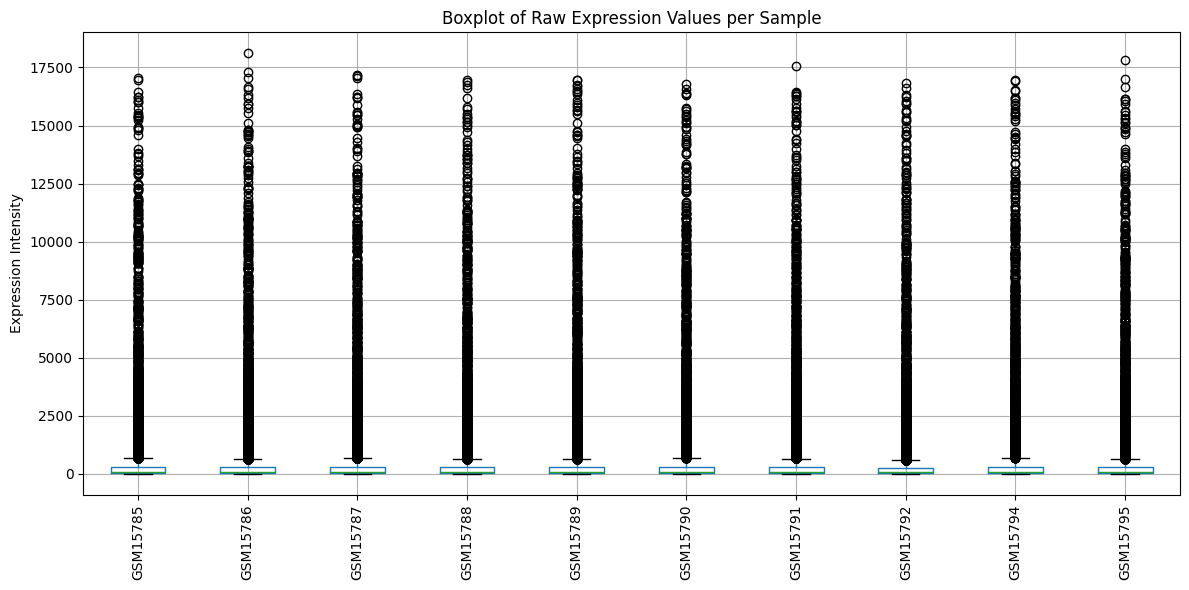

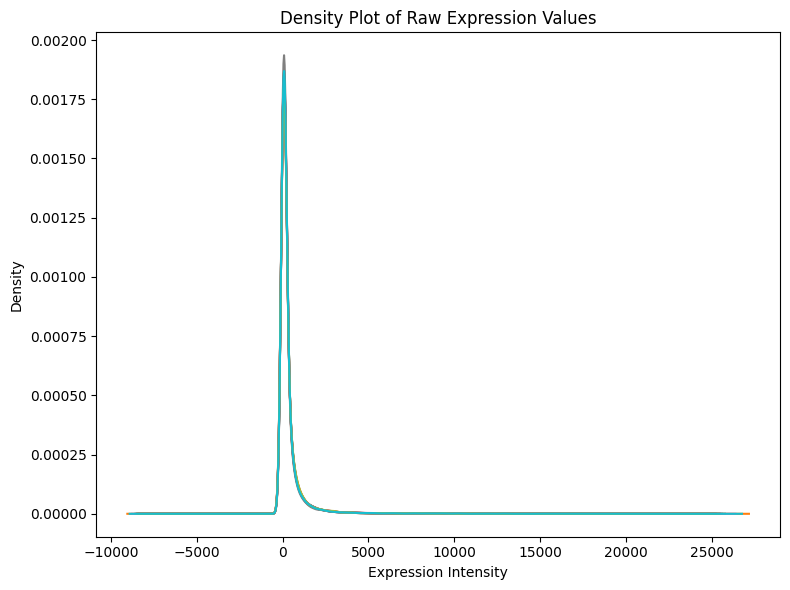

In [37]:

# Cell 1.5: Exploratory Data Analysis (EDA)
# Number of probes vs. samples
num_probes, num_cols = df_expr.shape
num_samples = num_cols
print(f"Number of probes: {num_probes}Number of samples: {num_samples}")

# Quick peek at the raw expression matrix
print("Top 5 rows of the expression matrix:")
print(df_expr.head())

# Distribution of expression values per sample (boxplot)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
df_expr.boxplot(rot=90)
plt.title('Boxplot of Raw Expression Values per Sample')
plt.ylabel('Expression Intensity')
plt.tight_layout()
plt.show()

# Density plot of expression values
df_expr.plot(kind='density', legend=False, figsize=(8, 6))
plt.title('Density Plot of Raw Expression Values')
plt.xlabel('Expression Intensity')
plt.tight_layout()
plt.show()


In [38]:
# Cell 2: Probe-to-Gene Annotation (optional)
try:
    import mygene
    mg = mygene.MyGeneInfo()
    res = mg.querymany(df_expr.index.tolist(), scopes='reporter', fields='symbol', species='human')
    map_df = pd.DataFrame(res).drop_duplicates('query').set_index('query')
    symbol_map = map_df['symbol'].to_dict()
    df_expr.index = [symbol_map.get(pid, pid) for pid in df_expr.index]
except ImportError:
    pass

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1097 input query terms found dup hits:	[('1007_s_at', 2), ('1294_at', 2), ('1773_at', 2), ('200003_s_at', 2), ('200012_x_at', 4), ('200016_
1377 input query terms found no hit:	['201205_at', '201265_at', '202015_x_at', '202091_at', '202280_at', '202881_x_at', '203326_x_at', '2


In [40]:
# Cell 3: Preprocessing & Normalization
from sklearn.preprocessing import StandardScaler

# Numeric conversion and missing-value filtering
df_expr = df_expr.apply(pd.to_numeric, errors='coerce')
df_expr.dropna(axis=0, inplace=True)
# Transpose: rows are samples, columns are genes
df_samples = df_expr.T
# Ensure all column names are strings to avoid mixed-type feature names
df_samples.columns = df_samples.columns.astype(str)

# Normalize per gene (center + scale each column)
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_samples.values)
df_scaled = pd.DataFrame(
    scaled_array,
    index=df_samples.index,
    columns=df_samples.columns
)
# Merge with metadata
df_scaled['sample_id'] = df_scaled.index
full_df = df_scaled.merge(meta_df, on='sample_id')


In [42]:
# Cell 4: Differential Expression Analysis
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

grp0 = full_df[full_df['condition_num']==0].drop(['sample_id','surface','time_point','condition_num'], axis=1)
grp1 = full_df[full_df['condition_num']==1].drop(['sample_id','surface','time_point','condition_num'], axis=1)

def compute_de(group_a, group_b):
    pvals, logFC = [], []
    for gene in group_a.columns:
        stat, p = stats.ttest_ind(group_a[gene], group_b[gene], equal_var=False)
        pvals.append(p)
        logFC.append(group_b[gene].mean() - group_a[gene].mean())
    return pvals, logFC

pvals, logFC = compute_de(grp0, grp1)
de_df = pd.DataFrame({'gene': grp0.columns, 'pval': pvals, 'logFC': logFC})
import pandas as pd
pval_array = pd.to_numeric(de_df['pval'], errors='coerce')
pval_array = pval_array.dropna()

# Ensure logFC matches (drop corresponding rows)
de_df = de_df.loc[pval_array.index]
_, adjp, _, _ = multipletests(pval_array, method='fdr_bh')
de_df['adj_pval'] = adjp
# Select DE genes
de_genes = de_df[(de_df['adj_pval']<0.05) & (de_df['logFC'].abs()>1)]['gene'].tolist()

KeyboardInterrupt: 

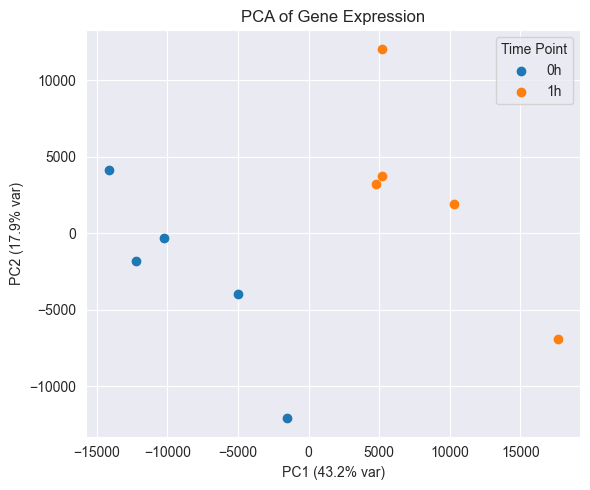

In [27]:
# Cell 7: PCA for Dimensionality Reduction and Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on scaled expression data
pca = PCA(n_components=2)
components = pca.fit_transform(df_samples.values)

# Build a DataFrame for plotting
pca_df = pd.DataFrame(
    components, columns=['PC1', 'PC2'],
    index=df_samples.index
).reset_index().rename(columns={'index': 'sample_id'})
pca_df = pca_df.merge(meta_df, on='sample_id')

# Plot PCA
plt.figure(figsize=(6, 5))
for label, df_sub in pca_df.groupby('condition_num'):
    plt.scatter(df_sub['PC1'], df_sub['PC2'], label=f"{label}h")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title('PCA of Gene Expression')
plt.legend(title='Time Point')
plt.tight_layout()
plt.show()

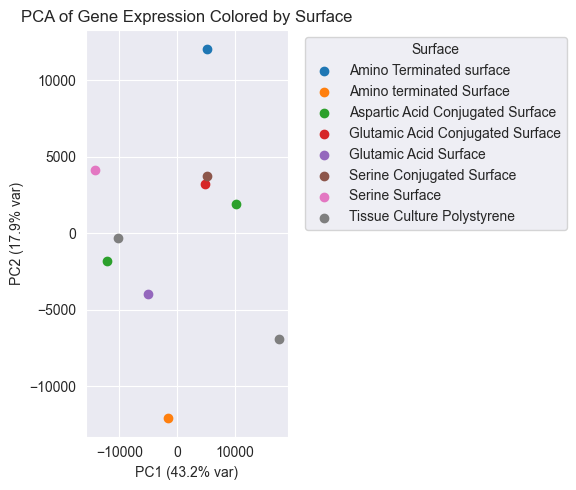

In [38]:
# Cell 7b: Surface-specific PCA
plt.figure(figsize=(6, 5))
for surface, df_sub in pca_df.groupby('surface'):
    plt.scatter(df_sub['PC1'], df_sub['PC2'], label=surface)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title('PCA of Gene Expression Colored by Surface')
plt.legend(title='Surface', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

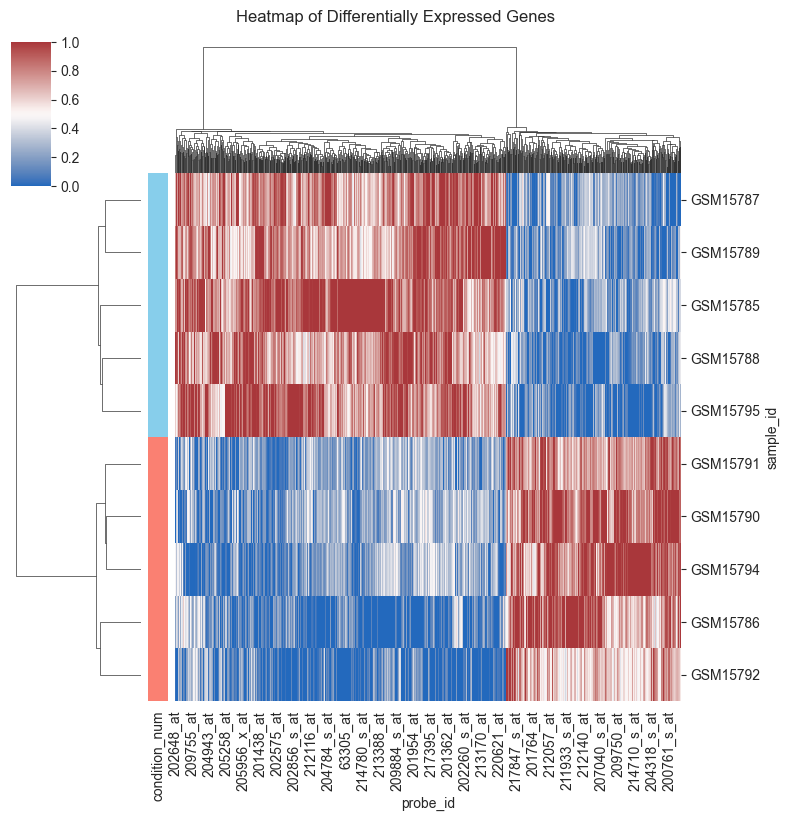

In [28]:
# Cell 8: Hierarchical Clustering and Heatmap of Top DE Genes
import seaborn as sns

# Subset scaled data to DE genes
de_matrix = df_scaled.set_index('sample_id')[de_genes]
# Reorder rows by condition
row_colors = full_df.set_index('sample_id')['condition_num'].map({0: 'skyblue', 1: 'salmon'})

# Plot heatmap
sns.clustermap(
    de_matrix, row_cluster=True, col_cluster=True,
    row_colors=row_colors, figsize=(8, 8), cmap='vlag', standard_scale=1
)
plt.suptitle('Heatmap of Differentially Expressed Genes', y=1.02)
plt.show()


Top 20 genes by Random Forest importance:
217763_s_at    0.020408
205596_s_at    0.020408
205574_x_at    0.020408
204440_at      0.020408
203043_at      0.020408
202812_at      0.020408
202174_s_at    0.020408
208963_x_at    0.020408
213524_s_at    0.020408
219197_s_at    0.010204
218869_at      0.010204
218650_at      0.010204
218695_at      0.010204
218627_at      0.010204
218017_s_at    0.010204
217989_at      0.010204
217161_x_at    0.010204
38158_at       0.010204
221877_at      0.010204
221741_s_at    0.010204
dtype: float64


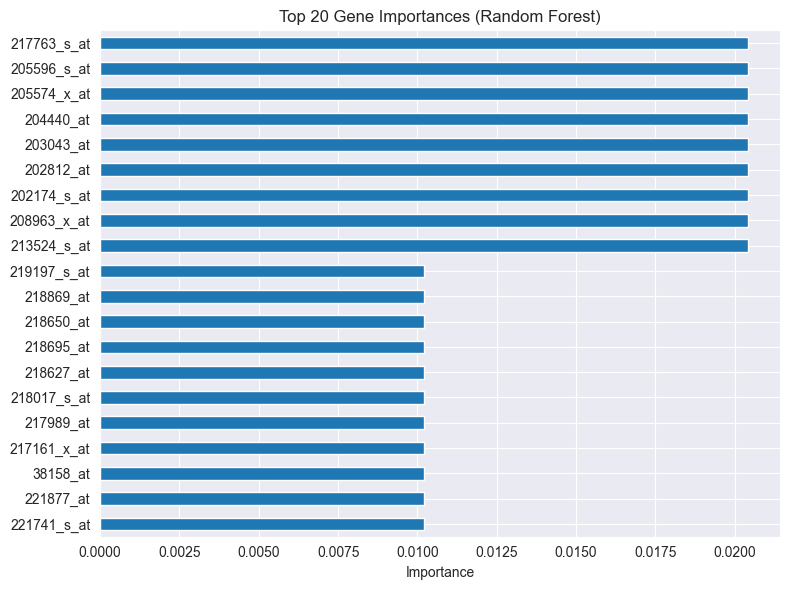

In [29]:
# Cell 9: Feature Importance via Random Forest
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train Random Forest on the training set
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extract feature importances
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

# Print top 20 important genes
print("Top 20 genes by Random Forest importance:")
print(feat_imp_sorted.head(20))

# Optional: Plot feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
feat_imp_sorted.head(20).plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 20 Gene Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


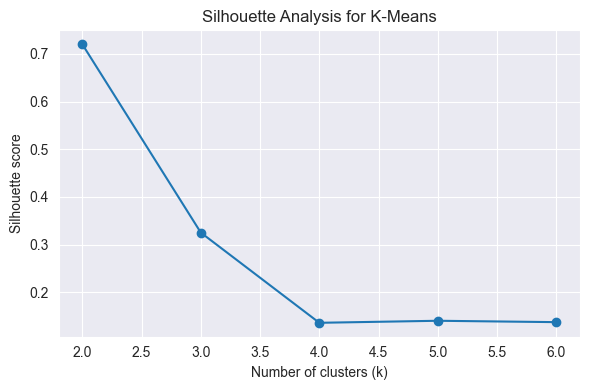

Optimal k for K-Means: 2
Cluster counts:
cluster
0    601
1    318
Name: count, dtype: int64
Agglomerative cluster counts:
agg_cluster
0    601
1    318
Name: count, dtype: int64


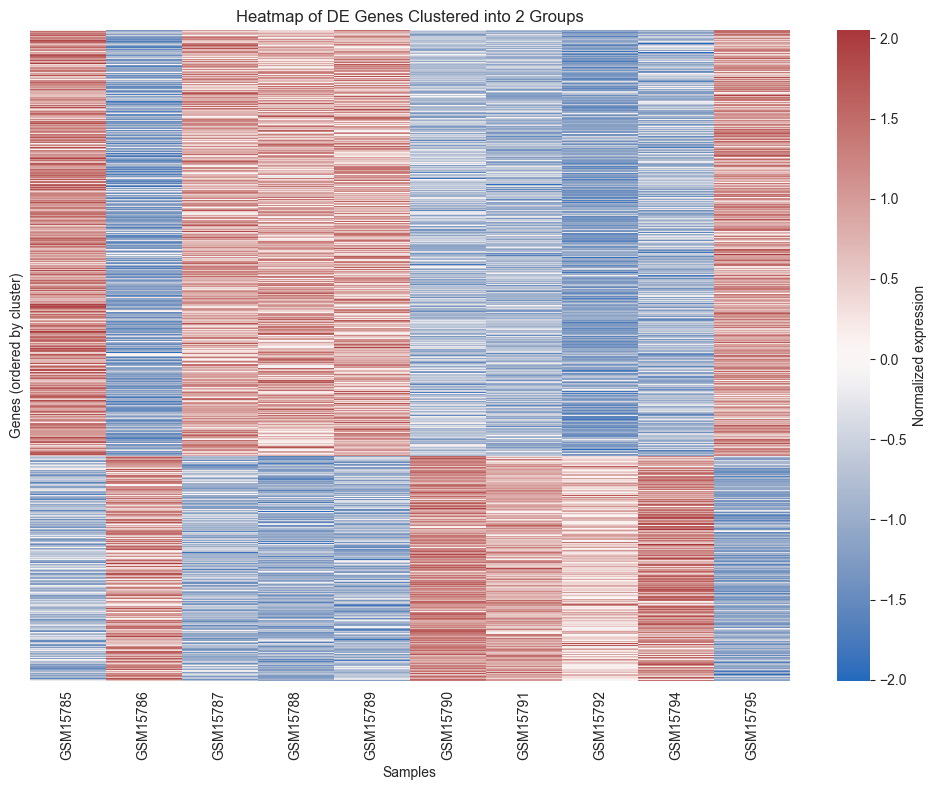

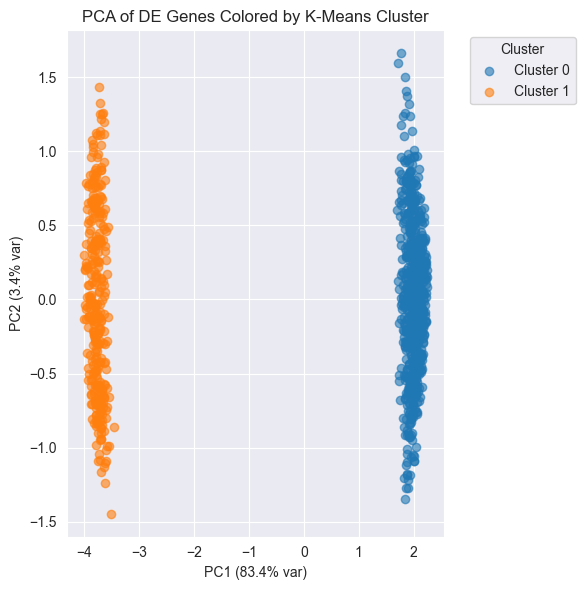

In [39]:
# Cell 10: Gene Clustering and Module Identification
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare gene expression matrix: genes x samples
gene_matrix = full_df.set_index('sample_id')[de_genes].T  # rows=genes, cols=samples

# 1) Silhouette analysis to choose k for K-Means
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(gene_matrix.values)
    sil = silhouette_score(gene_matrix.values, labels)
    sil_scores[k] = sil

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Analysis for K-Means')
plt.tight_layout()
plt.show()

# Choose k with highest silhouette score
best_k = max(sil_scores, key=sil_scores.get)
print(f"Optimal k for K-Means: {best_k}")

# 2) Run K-Means with optimal k
km = KMeans(n_clusters=best_k, random_state=42)
km_labels = km.fit_predict(gene_matrix.values)
cluster_df = pd.DataFrame({'gene': gene_matrix.index, 'cluster': km_labels})
print("Cluster counts:")
print(cluster_df['cluster'].value_counts())

# 3) Hierarchical clustering for comparison
auto = AgglomerativeClustering(n_clusters=best_k)
agg_labels = auto.fit_predict(gene_matrix.values)
cluster_df['agg_cluster'] = agg_labels
print("Agglomerative cluster counts:")
print(cluster_df['agg_cluster'].value_counts())

# 4) Heatmap of genes ordered by K-Means cluster
gene_order = cluster_df.sort_values('cluster')['gene']
ordered_matrix = gene_matrix.loc[gene_order]

plt.figure(figsize=(10, 8))
sns.heatmap(
    ordered_matrix, cmap='vlag', yticklabels=False,
    cbar_kws={'label': 'Normalized expression'}
)
plt.title(f'Heatmap of DE Genes Clustered into {best_k} Groups')
plt.xlabel('Samples')
plt.ylabel('Genes (ordered by cluster)')
plt.tight_layout()
plt.show()

# 5) PCA visualization of gene clusters
pca_genes = PCA(n_components=2)
gene_pcs = pca_genes.fit_transform(gene_matrix.values)

plt.figure(figsize=(6,6))
for clus in sorted(cluster_df['cluster'].unique()):
    indices = cluster_df[cluster_df['cluster']==clus].index
    plt.scatter(
        gene_pcs[indices, 0], gene_pcs[indices, 1], label=f"Cluster {clus}", alpha=0.6
    )
plt.xlabel(f"PC1 ({pca_genes.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_genes.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title('PCA of DE Genes Colored by K-Means Cluster')
plt.legend(title='Cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

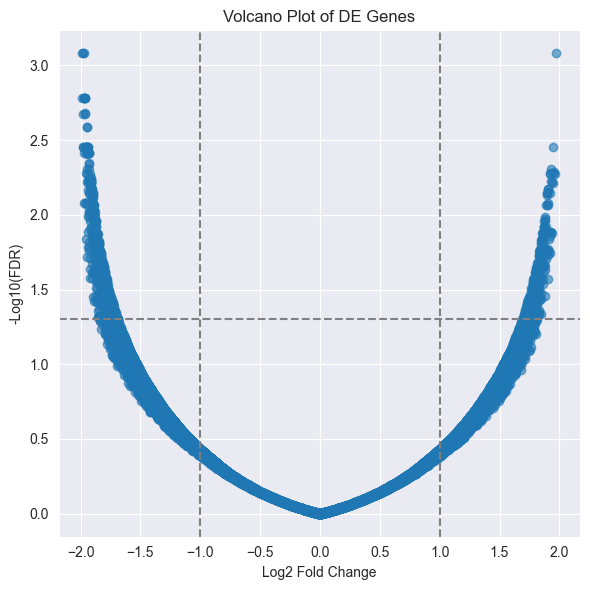

Top 10 upregulated genes:
              gene     logFC  adj_pval
9201   209714_s_at  1.974152  0.000831
17855  218491_s_at  1.963011  0.005295
12216  212832_s_at  1.953827  0.005186
1301   201774_s_at  1.946669  0.003537
10790  211375_s_at  1.945180  0.006082
8380     208886_at  1.942596  0.005270
7346   207828_s_at  1.939031  0.013143
12331    212949_at  1.938643  0.006014
18918  219555_s_at  1.930059  0.013022
11406  212021_s_at  1.927642  0.004900
Top 10 downregulated genes:
             gene     logFC  adj_pval
8443  208949_s_at -1.984723  0.001643
965     201438_at -1.984326  0.000831
3640    204114_at -1.983285  0.003500
4656    205130_at -1.976460  0.000831
2949    203423_at -1.976361  0.003500
8611  209118_s_at -1.976359  0.002128
7620  208112_x_at -1.974747  0.000831
1811  202284_s_at -1.974532  0.001643
6601  207076_s_at -1.974213  0.001643
1033    201506_at -1.970690  0.001643


In [34]:
# Cell 11: Differential Expression Visualization (Volcano Plot)
import matplotlib.pyplot as plt
import numpy as np

# Prepare volcano data
de_plot = de_df.copy()
de_plot['neg_log10_fdr'] = -np.log10(de_plot['adj_pval'])

plt.figure(figsize=(6,6))
plt.scatter(de_plot['logFC'], de_plot['neg_log10_fdr'], alpha=0.6)
# Threshold lines
plt.axhline(-np.log10(0.05), color='grey', linestyle='--')
plt.axvline(1, color='grey', linestyle='--')
plt.axvline(-1, color='grey', linestyle='--')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10(FDR)')
plt.title('Volcano Plot of DE Genes')
plt.tight_layout()
plt.show()

# List top up/down regulated genes
top_up = de_plot[(de_plot['adj_pval']<0.05) & (de_plot['logFC']>1)].sort_values('logFC', ascending=False).head(10)
top_down = de_plot[(de_plot['adj_pval']<0.05) & (de_plot['logFC']<-1)].sort_values('logFC').head(10)
print("Top 10 upregulated genes:")
print(top_up[['gene','logFC','adj_pval']])
print("Top 10 downregulated genes:")
print(top_down[['gene','logFC','adj_pval']])


In [40]:
# Cell 12: Export and Review Differential Expression Results
# Extract all significant DE genes (FDR<0.05, |logFC|>1)
sig_de = de_df[(de_df['adj_pval']<0.05) & (de_df['logFC'].abs()>1)].sort_values('adj_pval')
# Save to CSV
sig_de.to_csv('GSE1000_DE_genes.csv', index=False)
# Print summary
print(f"Total significant DE genes: {sig_de.shape[0]}")
print("First 20 significant DE genes:")
print(sig_de.head(20))

Total significant DE genes: 919
First 20 significant DE genes:
              gene          pval     logFC  adj_pval
965      201438_at  1.433288e-07 -1.984326  0.000831
9201   209714_s_at  1.202440e-07  1.974152  0.000831
7620   208112_x_at  1.491542e-07 -1.974747  0.000831
4656     205130_at  1.083291e-07 -1.976460  0.000831
1387   201860_s_at  6.872072e-07 -1.960056  0.001643
4271   204745_x_at  5.210895e-07 -1.962637  0.001643
1811   202284_s_at  8.109445e-07 -1.974532  0.001643
9389     209904_at  5.504110e-07 -1.965392  0.001643
8443   208949_s_at  7.594611e-07 -1.984723  0.001643
1033     201506_at  5.908790e-07 -1.970690  0.001643
6601   207076_s_at  4.479461e-07 -1.974213  0.001643
1931   202404_s_at  1.117857e-06 -1.962133  0.002076
8611   209118_s_at  1.336980e-06 -1.976359  0.002128
10602  211161_s_at  1.249279e-06 -1.959829  0.002128
3405     203879_at  1.800773e-06 -1.949589  0.002588
2102     202575_at  1.858188e-06 -1.949912  0.002588
12494  213112_s_at  2.749498e-06 -1.

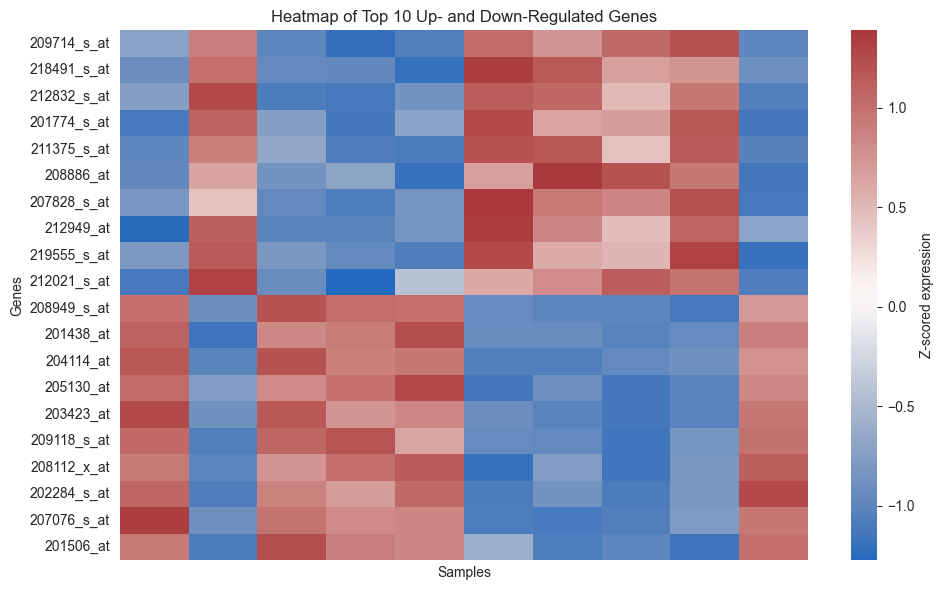

In [41]:
# Cell 13: Heatmap of Top Differentially Expressed Genes Across Samples
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 10 up- and down-regulated genes
top_genes = pd.concat([top_up['gene'], top_down['gene']])

# Subset scaled data for these genes
gene_heat = full_df.set_index('sample_id')[top_genes]
# Reorder columns so up genes then down genes
gene_heat = gene_heat[top_genes.tolist()]
# Create a DataFrame for heatmap with condition annotation
gene_heat.index.name = 'sample_id'

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    gene_heat.T,  # genes on rows
    cmap='vlag',
    cbar_kws={'label': 'Z-scored expression'},
    yticklabels=True,
    xticklabels=False
)
plt.title('Heatmap of Top 10 Up- and Down-Regulated Genes')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()


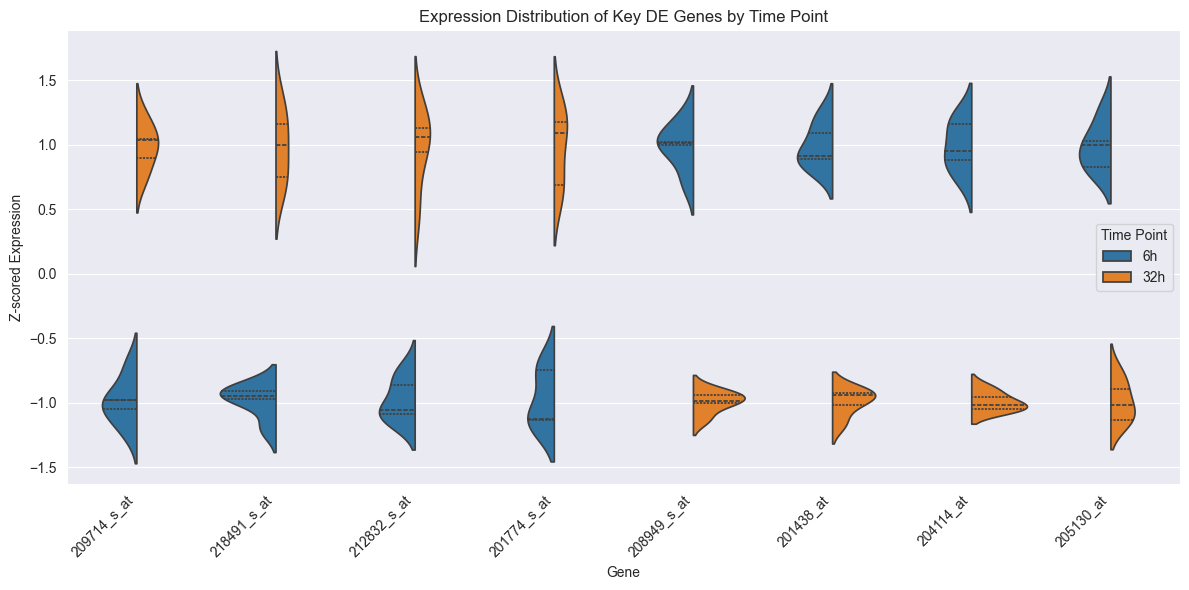

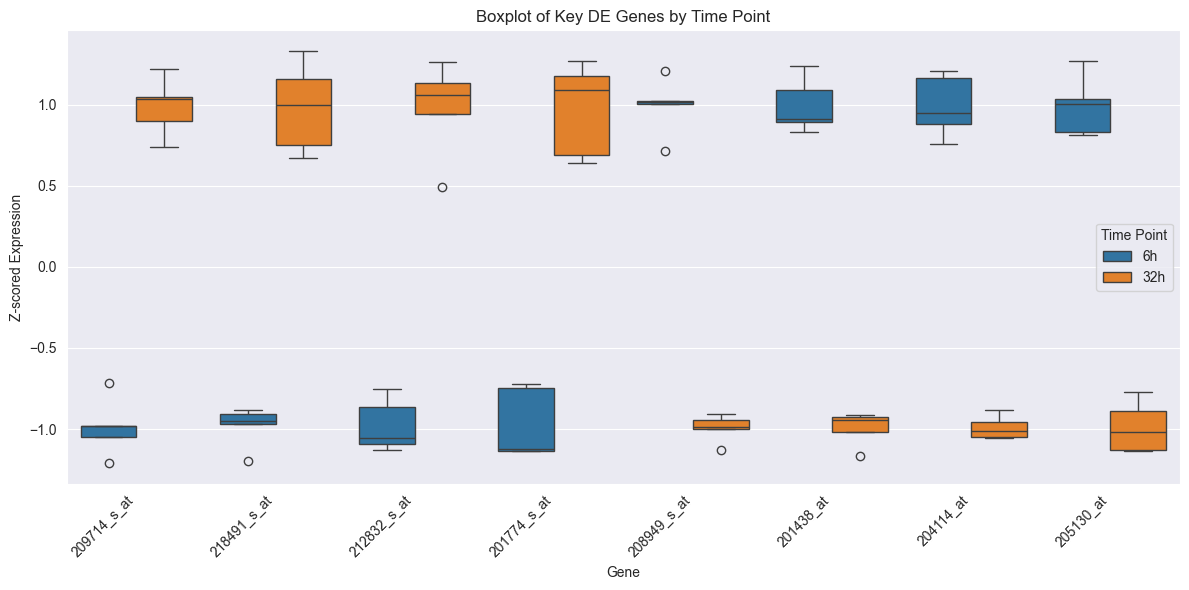

In [42]:
# Cell 14: Violin and Boxplots for Key Genes
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the scaled expression of key genes for plotting
key_genes = top_up['gene'].head(4).tolist() + top_down['gene'].head(4).tolist()
plot_df = full_df[['sample_id','condition_num'] + key_genes].melt(
    id_vars=['sample_id','condition_num'],
    value_vars=key_genes,
    var_name='gene',
    value_name='expression'
)
# Map condition_num back to labels
plot_df['condition'] = plot_df['condition_num'].map({0: '6h', 1: '32h'})

# Violin plot
plt.figure(figsize=(12,6))
sns.violinplot(
    x='gene', y='expression', hue='condition',
    data=plot_df, split=True, inner='quartile'
)
plt.title('Expression Distribution of Key DE Genes by Time Point')
plt.xlabel('Gene')
plt.ylabel('Z-scored Expression')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Point')
plt.tight_layout()
plt.show()

# Boxplot as an alternative
plt.figure(figsize=(12,6))
sns.boxplot(
    x='gene', y='expression', hue='condition',
    data=plot_df
)
plt.title('Boxplot of Key DE Genes by Time Point')
plt.xlabel('Gene')
plt.ylabel('Z-scored Expression')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Point')
plt.tight_layout()
plt.show()
